In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
feats = pd.read_csv('sway_features.csv')
demo_df = pd.read_excel('SwayDemographics.xlsx')
feats['cohort'].value_counts()

cohort
C    70
M    52
Name: count, dtype: int64

In [3]:
demo_df

,ID,Grp,Sex,Age,Ethnicity,Race,Height,Weight,BMI,BMI Cat,...,MS Onset,MS Dur,BDI Rank,BDI Raw Score,MFIS Phys,MFIS Cog,MFIS Psych,MFIS Total,MS FSS,EDSS Total
0,M-01,MS,1,21,0.0,1,188.00,149.200,42.213671,4,...,11,10,3,19,3,8,2,13,10,1.5
1,M-02,MS,1,17,0.0,1,181.60,65.400,19.831066,2,...,14,3,1,1,0,0,0,0,9,1
2,M-03,MS,2,15,0.0,1,161.00,71.390,27.541376,3,...,7,8,1,7,18,23,1,42,28,1.5
3,M-04,MS,1,14,0.0,1,172.10,70.490,23.799387,3,...,13,1,1,3,14,6,1,21,24,2
4,M-05,MS,2,19,0.0,4,166.40,58.786,21.230844,2,...,17,2,0,0,1,0,0,1,9,0
5,M-06,MS,2,12,0.0,1,150.90,51.170,22.477710,3,...,11,1,0,0,0,0,0,0,9,1.5
6,M-07,MS,2,18,0.0,1,155.00,50.350,20.957336,2,...,14,4,1,10,10,20,2,32,23,1.5
7,M-08,MS,1,21,0.0,1,177.30,69.310,22.048468,2,...,12,9,4,21,15,6,2,23,16,2.5
8,M-09,MS,2,19,0.0,4,175.40,87.900,28.571280,3,...,16,3,0,0,13,16,2,31,21,2
9,M-10,MS,2,18,0.0,1,165.90,55.970,20.335860,2,...,17,1,1,3,14,2,2,18,19,2


In [4]:
# extract numeric part of the original ID
demo_df["ID"] = demo_df["ID"].str.extract(r'-(\d+)').astype(int)

# recode group column
demo_df["Grp"] = demo_df["Grp"].map({"Control": "C", "MS": "M"})
demo_df

,ID,Grp,Sex,Age,Ethnicity,Race,Height,Weight,BMI,BMI Cat,...,MS Onset,MS Dur,BDI Rank,BDI Raw Score,MFIS Phys,MFIS Cog,MFIS Psych,MFIS Total,MS FSS,EDSS Total
0,1,M,1,21,0.0,1,188.00,149.200,42.213671,4,...,11,10,3,19,3,8,2,13,10,1.5
1,2,M,1,17,0.0,1,181.60,65.400,19.831066,2,...,14,3,1,1,0,0,0,0,9,1
2,3,M,2,15,0.0,1,161.00,71.390,27.541376,3,...,7,8,1,7,18,23,1,42,28,1.5
3,4,M,1,14,0.0,1,172.10,70.490,23.799387,3,...,13,1,1,3,14,6,1,21,24,2
4,5,M,2,19,0.0,4,166.40,58.786,21.230844,2,...,17,2,0,0,1,0,0,1,9,0
5,6,M,2,12,0.0,1,150.90,51.170,22.477710,3,...,11,1,0,0,0,0,0,0,9,1.5
6,7,M,2,18,0.0,1,155.00,50.350,20.957336,2,...,14,4,1,10,10,20,2,32,23,1.5
7,8,M,1,21,0.0,1,177.30,69.310,22.048468,2,...,12,9,4,21,15,6,2,23,16,2.5
8,9,M,2,19,0.0,4,175.40,87.900,28.571280,3,...,16,3,0,0,13,16,2,31,21,2
9,10,M,2,18,0.0,1,165.90,55.970,20.335860,2,...,17,1,1,3,14,2,2,18,19,2


In [5]:
demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             150 non-null    int64  
 1   Grp            150 non-null    object 
 2   Sex            150 non-null    int64  
 3   Age            150 non-null    int64  
 4   Ethnicity      65 non-null     float64
 5   Race           150 non-null    int64  
 6   Height         150 non-null    float64
 7   Weight         150 non-null    float64
 8   BMI            150 non-null    float64
 9   BMI Cat        150 non-null    int64  
 10  Waist          150 non-null    object 
 11  MS Onset       150 non-null    object 
 12  MS Dur         150 non-null    object 
 13  BDI Rank       150 non-null    int64  
 14  BDI Raw Score  150 non-null    int64  
 15  MFIS Phys      150 non-null    int64  
 16  MFIS Cog       150 non-null    int64  
 17  MFIS Psych     150 non-null    int64  
 18  MFIS Total

In [6]:
feats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cohort                 103 non-null    object 
 1   subj_id                103 non-null    int64  
 2   year_x                 103 non-null    int64  
 3   sixmwd                 103 non-null    int64  
 4   fs                     103 non-null    float64
 5   cadence_hz             103 non-null    float64
 6   step_time_cv_pct       103 non-null    float64
 7   acf_step_regularity    103 non-null    float64
 8   hr_ap                  103 non-null    float64
 9   hr_vt                  103 non-null    float64
 10  ml_rms_g               103 non-null    float64
 11  ml_spectral_entropy    103 non-null    float64
 12  jerk_mean_abs_gps      103 non-null    float64
 13  enmo_mean_g            103 non-null    float64
 14  cadence_slope_per_min  103 non-null    float64
 15  year_y

In [6]:
feats["Grp"] = feats["cohort"]

demo_df["ID"] = demo_df["ID"].astype(int)
feats["subj_id"] = feats["subj_id"].astype(int)

mdf = demo_df.merge(
    feats,
    left_on=["Grp", "ID"],
    right_on=["Grp", "subj_id"],
    how="inner"
)

mdf

,ID,Grp,Sex,Age,Ethnicity,Race,Height,Weight,BMI,BMI Cat,...,hr_vt,ml_rms_g,ml_spectral_entropy,jerk_mean_abs_gps,enmo_mean_g,cadence_slope_per_min,year_y,vt_rms_g,ml_over_enmo,ml_over_vt
0,1,M,1,21,0.0,1,188.00,149.200,42.213671,4,...,0.004699,0.256010,0.683111,7.114569,0.230232,3.515625e-02,2016,0.488413,1.111965,0.524167
1,2,M,1,17,0.0,1,181.60,65.400,19.831066,2,...,0.003826,0.136732,0.771633,5.869748,0.191240,-3.254849e-16,2016,0.393562,0.714977,0.347422
2,4,M,1,14,0.0,1,172.10,70.490,23.799387,3,...,0.003346,0.189981,0.752812,7.519001,0.284329,3.515625e-02,2016,0.565688,0.668173,0.335841
3,5,M,2,19,0.0,4,166.40,58.786,21.230844,2,...,0.030876,0.255650,0.785314,9.293667,0.300187,1.171875e-02,2016,0.586219,0.851635,0.436100
4,6,M,2,12,0.0,1,150.90,51.170,22.477710,3,...,0.000965,0.145322,0.819745,7.673763,0.214764,-3.515625e-02,2016,0.457302,0.676658,0.317781
5,7,M,2,18,0.0,1,155.00,50.350,20.957336,2,...,0.002251,0.137941,0.783885,8.213079,0.280524,-2.343750e-02,2016,0.567611,0.491727,0.243021
6,8,M,1,21,0.0,1,177.30,69.310,22.048468,2,...,0.019477,0.229429,0.750391,8.621974,0.299095,2.343750e-02,2016,0.572322,0.767077,0.400874
7,9,M,2,19,0.0,4,175.40,87.900,28.571280,3,...,0.007640,0.174694,0.562573,4.497779,0.178567,-3.254849e-16,2016,0.384383,0.978308,0.454479
8,10,M,2,18,0.0,1,165.90,55.970,20.335860,2,...,0.016091,0.268082,0.748316,9.746644,0.276922,-2.343750e-02,2016,0.553546,0.968077,0.484299
9,11,M,2,21,0.0,1,172.80,78.200,26.189022,3,...,0.006686,0.266845,0.782629,8.623780,0.323330,-1.030986e-16,2016,0.625929,0.825305,0.426319


In [7]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     122 non-null    int64  
 1   Grp                    122 non-null    object 
 2   Sex                    122 non-null    int64  
 3   Age                    122 non-null    int64  
 4   Ethnicity              52 non-null     float64
 5   Race                   122 non-null    int64  
 6   Height                 122 non-null    float64
 7   Weight                 122 non-null    float64
 8   BMI                    122 non-null    float64
 9   BMI Cat                122 non-null    int64  
 10  Waist                  122 non-null    object 
 11  MS Onset               122 non-null    object 
 12  MS Dur                 122 non-null    object 
 13  BDI Rank               122 non-null    int64  
 14  BDI Raw Score          122 non-null    int64  
 15  MFIS P

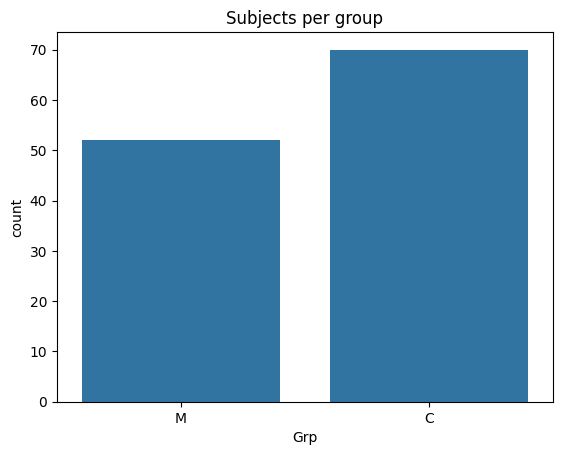

In [8]:
sns.countplot(data=mdf, x="Grp")
plt.title("Subjects per group")
plt.show()

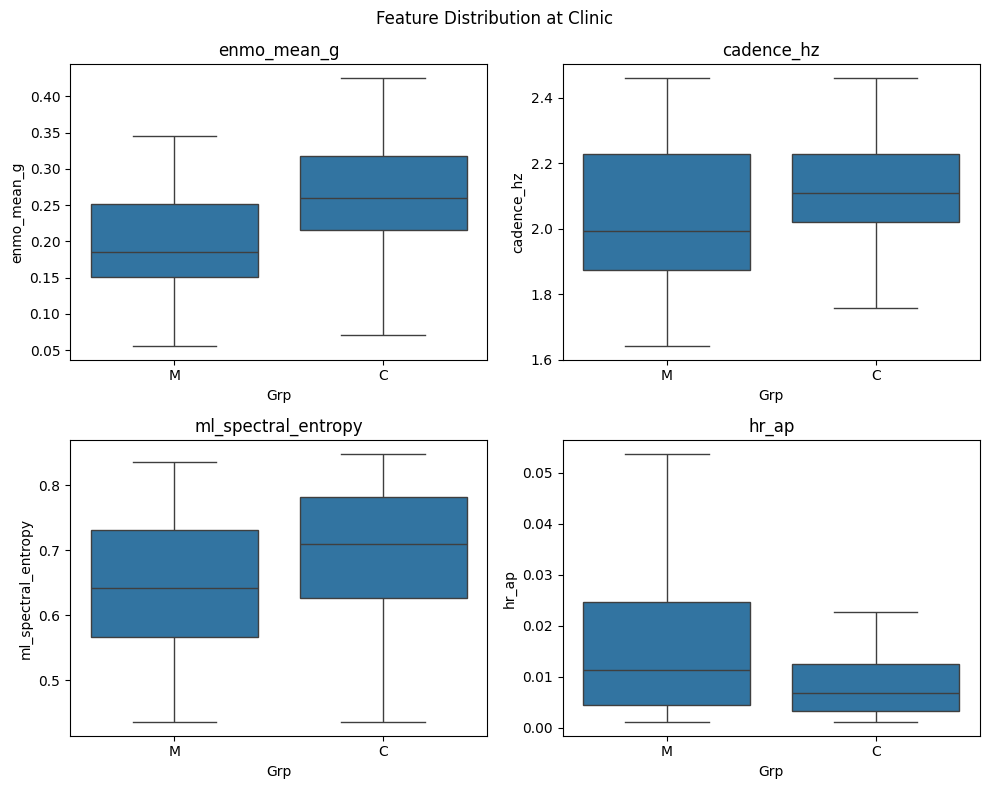

In [18]:
import math

gait_cols = [
    "enmo_mean_g",
    "cadence_hz",
    "ml_spectral_entropy",
    "hr_ap",
]

ncols = 2
nrows = math.ceil(len(gait_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(gait_cols):
    ax = axes[i]

    # copy column only for plotting
    plot_df = mdf.copy()

    # percentile clipping (robust visualization, does NOT modify real data)
    lo = plot_df[col].quantile(0.01)
    hi = plot_df[col].quantile(0.99)
    plot_df[col] = plot_df[col].clip(lo, hi)

    # boxplot without fliers
    sns.boxplot(data=plot_df, x="Grp", y=col, ax=ax, showfliers=False)

    # points
    # sns.stripplot(data=plot_df, x="Grp", y=col, color="black", alpha=0.4, ax=ax)

    ax.set_title(col)

# remove unused axes
for j in range(len(gait_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distribution at Clinic')
plt.tight_layout()
plt.savefig('Feature_Dist.png',dpi=300,bbox_inches='tight')
plt.show()


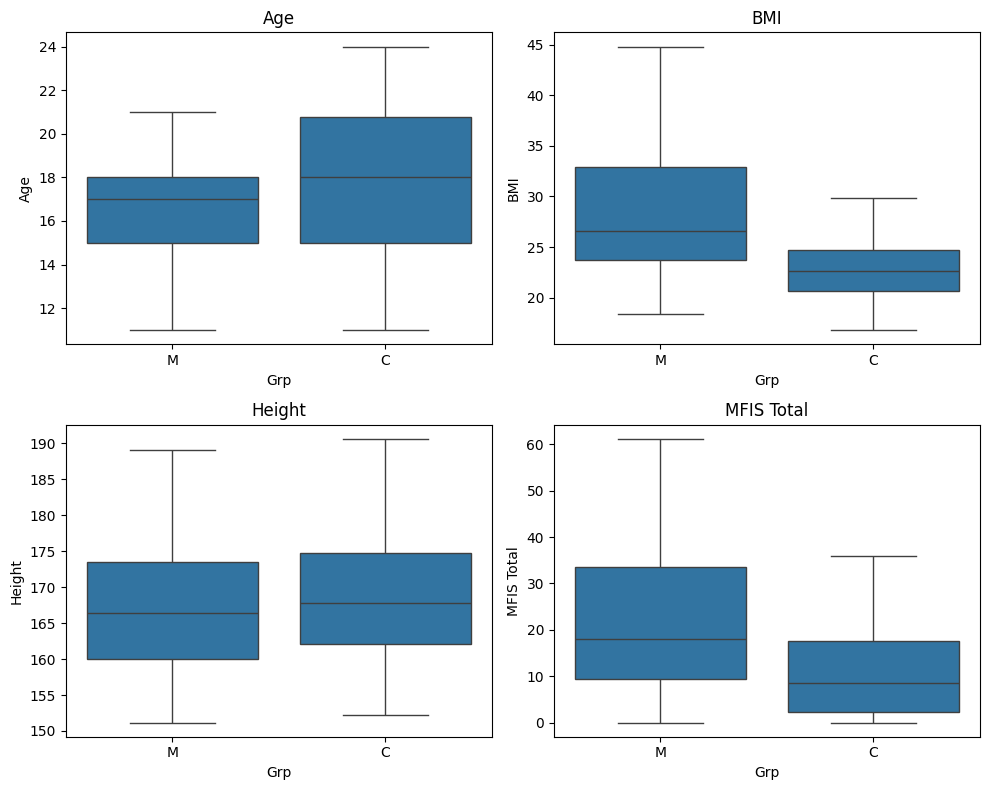

In [10]:
import math

gait_cols = [
    "Age",
    "BMI",
    "Height",
    "MFIS Total",
    
]

ncols = 2
nrows = math.ceil(len(gait_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(gait_cols):
    ax = axes[i]

    # copy column only for plotting
    plot_df = mdf.copy()

    # percentile clipping (robust visualization, does NOT modify real data)
    lo = plot_df[col].quantile(0.01)
    hi = plot_df[col].quantile(0.99)
    plot_df[col] = plot_df[col].clip(lo, hi)

    # boxplot without fliers
    sns.boxplot(data=plot_df, x="Grp", y=col, ax=ax, showfliers=False)

    # points
    # sns.stripplot(data=plot_df, x="Grp", y=col, color="black", alpha=0.4, ax=ax)

    ax.set_title(col)

# remove unused axes
for j in range(len(gait_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


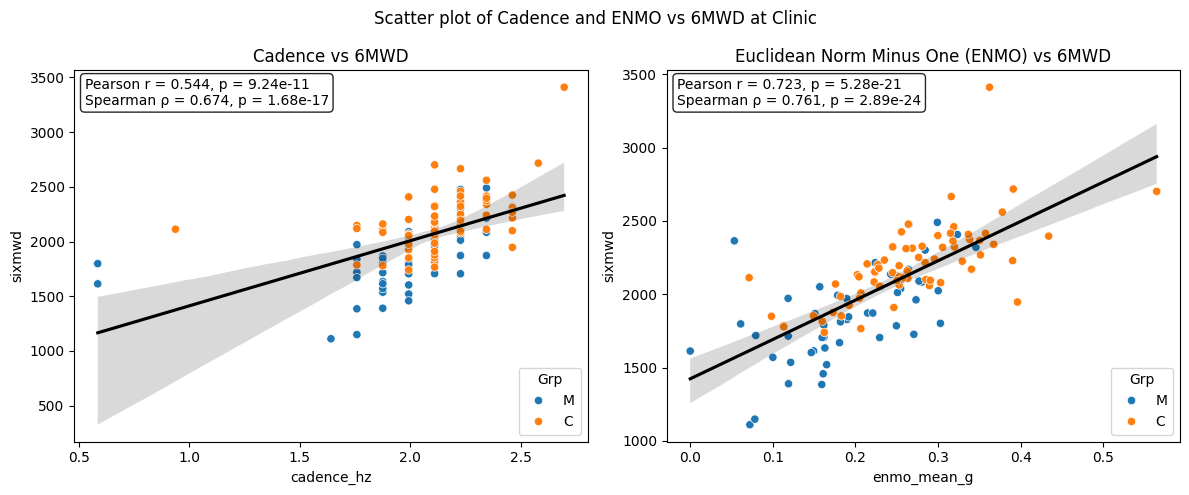

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

pairs = [
    ("cadence_hz", "Cadence"),
    ("enmo_mean_g", "Euclidean Norm Minus One (ENMO)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (col, label) in zip(axes, pairs):

    x = mdf[col]
    y = mdf["sixmwd"]

    # correlations
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    # plot
    sns.scatterplot(data=mdf, x=col, y="sixmwd", hue="Grp", ax=ax)
    sns.regplot(data=mdf, x=col, y="sixmwd", scatter=False, color="black", ax=ax)

    # annotation
    text = (
        f"Pearson r = {r_p:.3f}, p = {p_p:.3g}\n"
        f"Spearman ρ = {r_s:.3f}, p = {p_s:.3g}"
    )

    ax.text(
        0.02, 0.98, text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(f"{label} vs 6MWD")

plt.suptitle('Scatter plot of Cadence and ENMO vs 6MWD at Clinic')
plt.tight_layout()
plt.savefig('scatter_correlation.png',dpi=300,bbox_inches='tight')
plt.show()

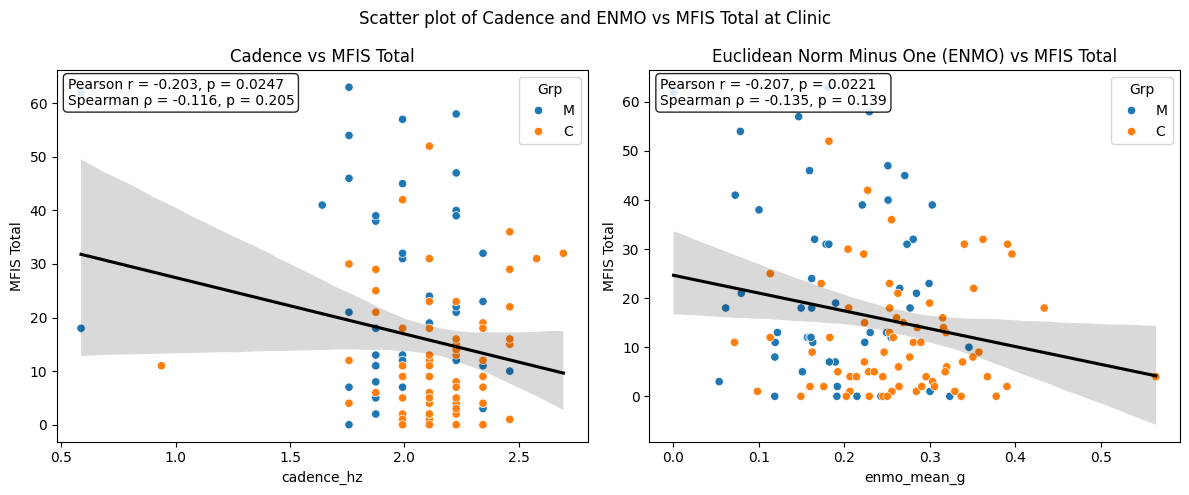

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

pairs = [
    ("cadence_hz", "Cadence"),
    ("enmo_mean_g", "Euclidean Norm Minus One (ENMO)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, (col, label) in zip(axes, pairs):

    x = mdf[col]
    y = mdf["MFIS Total"]

    # correlations
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    # plot
    sns.scatterplot(data=mdf, x=col, y="MFIS Total", hue="Grp", ax=ax)
    sns.regplot(data=mdf, x=col, y="MFIS Total", scatter=False, color="black", ax=ax)

    # annotation
    text = (
        f"Pearson r = {r_p:.3f}, p = {p_p:.3g}\n"
        f"Spearman ρ = {r_s:.3f}, p = {p_s:.3g}"
    )

    ax.text(
        0.02, 0.98, text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(f"{label} vs MFIS Total")
plt.suptitle('Scatter plot of Cadence and ENMO vs MFIS Total at Clinic')
plt.tight_layout()
plt.savefig('scatter_correlation_mfis.png',dpi=300,bbox_inches='tight')
plt.show()

In [13]:
from scipy.stats import spearmanr, pearsonr
import pandas as pd

target = "MFIS Total"

gait_features = [
    "cadence_hz",
    "step_time_cv_pct",
    "acf_step_regularity",
    "hr_ap",
    "hr_vt",
    "ml_rms_g",
    "ml_spectral_entropy",
    "jerk_mean_abs_gps",
    "enmo_mean_g",
    "cadence_slope_per_min",
    "vt_rms_g",
    "ml_over_enmo",
    "ml_over_vt"
]

rows = []

for col in gait_features:
    x = mdf[col]
    y = mdf[target]

    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    rows.append({
        "feature": col,
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s,
        "abs_spearman": abs(r_s)
    })

corr_df = pd.DataFrame(rows)

# sort strongest → weakest association (clinical convention uses |Spearman|)
corr_df = corr_df.sort_values("abs_spearman", ascending=False)

corr_df = corr_df.drop(columns="abs_spearman")

corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
11,ml_over_enmo,0.291734,0.001113,0.178465,0.049214
12,ml_over_vt,0.269508,0.002683,0.169351,0.062213
8,enmo_mean_g,-0.207134,0.022067,-0.134873,0.138565
10,vt_rms_g,-0.232802,0.009867,-0.131333,0.149320
0,cadence_hz,-0.203337,0.024683,-0.115603,0.204803
6,ml_spectral_entropy,-0.120790,0.185074,-0.099233,0.276829
1,step_time_cv_pct,0.034351,0.707193,0.088353,0.333178
7,jerk_mean_abs_gps,-0.135761,0.135960,-0.080208,0.379825
9,cadence_slope_per_min,-0.008565,0.925404,-0.059692,0.513680
5,ml_rms_g,-0.089211,0.328482,-0.044171,0.629024


In [14]:
mdf["EDSS Total"] = pd.to_numeric(mdf["EDSS Total"], errors="coerce")
mdf_edss = mdf.dropna(subset=["EDSS Total"]).copy()

target = "EDSS Total"

gait_features = [
    "cadence_hz",
    "step_time_cv_pct",
    "acf_step_regularity",
    "hr_ap",
    "hr_vt",
    "ml_rms_g",
    "ml_spectral_entropy",
    "jerk_mean_abs_gps",
    "enmo_mean_g",
    "cadence_slope_per_min",
    "vt_rms_g",
    "ml_over_enmo",
    "ml_over_vt"
]

rows = []

for col in gait_features:
    x = mdf_edss[col]
    y = mdf_edss[target]

    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    rows.append({
        "feature": col,
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s,
        "abs_spearman": abs(r_s)
    })

corr_df = pd.DataFrame(rows)

# sort strongest → weakest association (clinical convention uses |Spearman|)
corr_df = corr_df.sort_values("abs_spearman", ascending=False)

corr_df = corr_df.drop(columns="abs_spearman")

corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
2,acf_step_regularity,0.112783,0.425995,0.154963,0.272670
6,ml_spectral_entropy,-0.148136,0.294615,-0.130951,0.354791
4,hr_vt,-0.050786,0.720679,0.127175,0.368953
11,ml_over_enmo,-0.028555,0.840739,0.107552,0.447898
9,cadence_slope_per_min,-0.218107,0.120346,-0.094726,0.504146
3,hr_ap,-0.060400,0.670582,-0.073443,0.604856
0,cadence_hz,-0.013978,0.921655,-0.073264,0.605736
12,ml_over_vt,0.081366,0.566356,0.042055,0.767212
7,jerk_mean_abs_gps,-0.043372,0.760137,-0.034505,0.808129
5,ml_rms_g,0.035836,0.800871,0.033451,0.813882


In [17]:
mdf.columns

Index(['ID', 'Grp', 'Sex', 'Age', 'Ethnicity', 'Race', 'Height', 'Weight',
       'BMI', 'BMI Cat', 'Waist', 'MS Onset', 'MS Dur', 'BDI Rank',
       'BDI Raw Score', 'MFIS Phys', 'MFIS Cog', 'MFIS Psych', 'MFIS Total',
       'MS FSS', 'EDSS Total', 'cohort', 'subj_id', 'year_x', 'sixmwd', 'fs',
       'cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap',
       'hr_vt', 'ml_rms_g', 'ml_spectral_entropy', 'jerk_mean_abs_gps',
       'enmo_mean_g', 'cadence_slope_per_min', 'year_y', 'vt_rms_g',
       'ml_over_enmo', 'ml_over_vt'],
      dtype='object')

In [26]:
demo_df = mdf[['Age', 'BMI', 'Height', 'Weight', 'sixmwd','cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']]

cdf = mdf[['MS Dur', 'BDI Rank','BDI Raw Score', 'MFIS Phys', 'MFIS Cog', 
           'MFIS Psych', 'MFIS Total','MS FSS', 'EDSS Total','sixmwd',
           'cadence_hz', 'step_time_cv_pct', 'acf_step_regularity', 'hr_ap','hr_vt', 'ml_rms_g', 
           'ml_spectral_entropy', 'jerk_mean_abs_gps','enmo_mean_g', 'cadence_slope_per_min', 'vt_rms_g',
           'ml_over_enmo', 'ml_over_vt']]



demo_df = demo_df.replace(".", np.nan)               # or {".": np.nan}
demo_df = demo_df.apply(pd.to_numeric, errors="coerce")     

cdf = cdf.replace(".", np.nan)               # or {".": np.nan}
cdf = cdf.apply(pd.to_numeric, errors="coerce")     

/tmp/ipykernel_1197457/228081365.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cdf = cdf.replace(".", np.nan)               # or {".": np.nan}


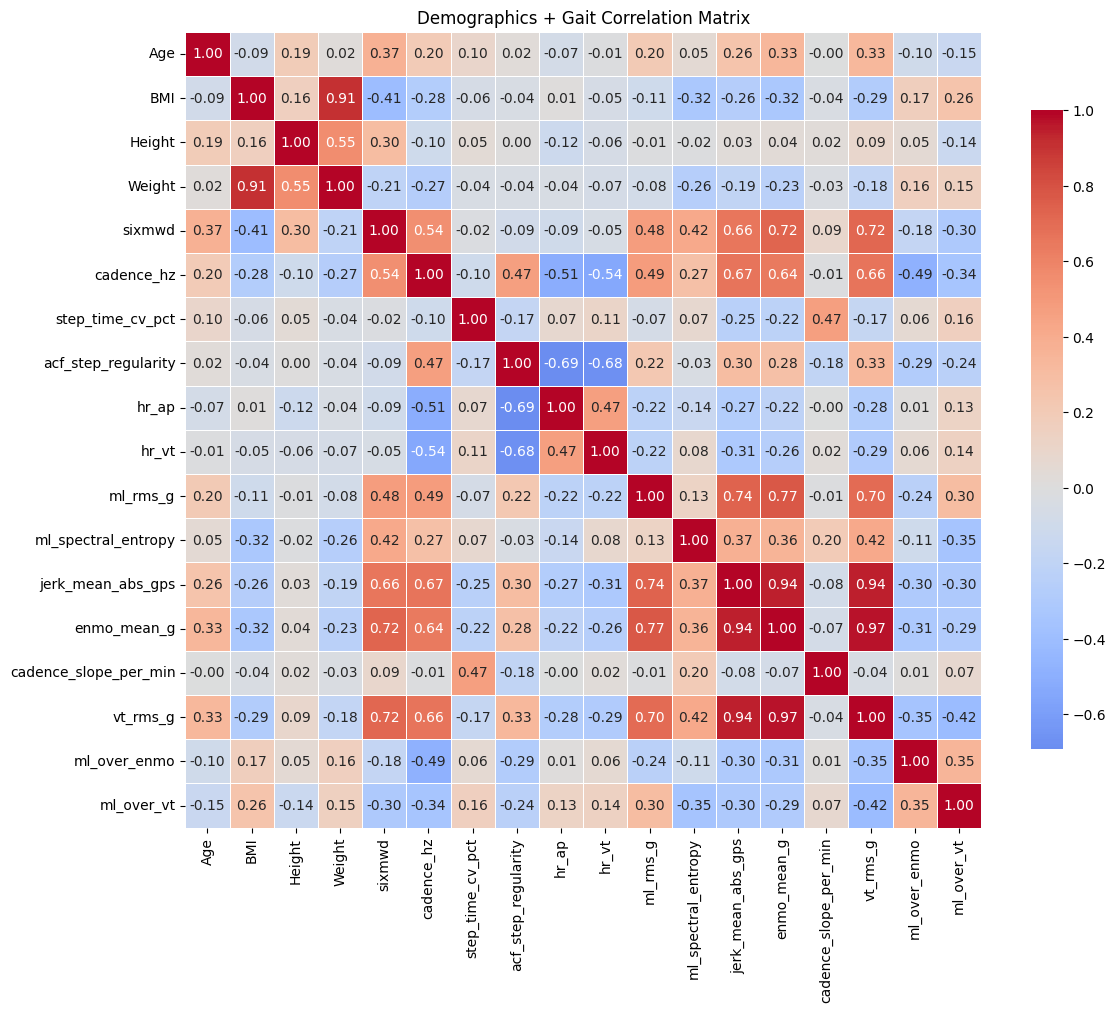

In [29]:
corr = demo_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)
plt.title("Demographics + Gait Correlation Matrix")
plt.tight_layout()
plt.show()

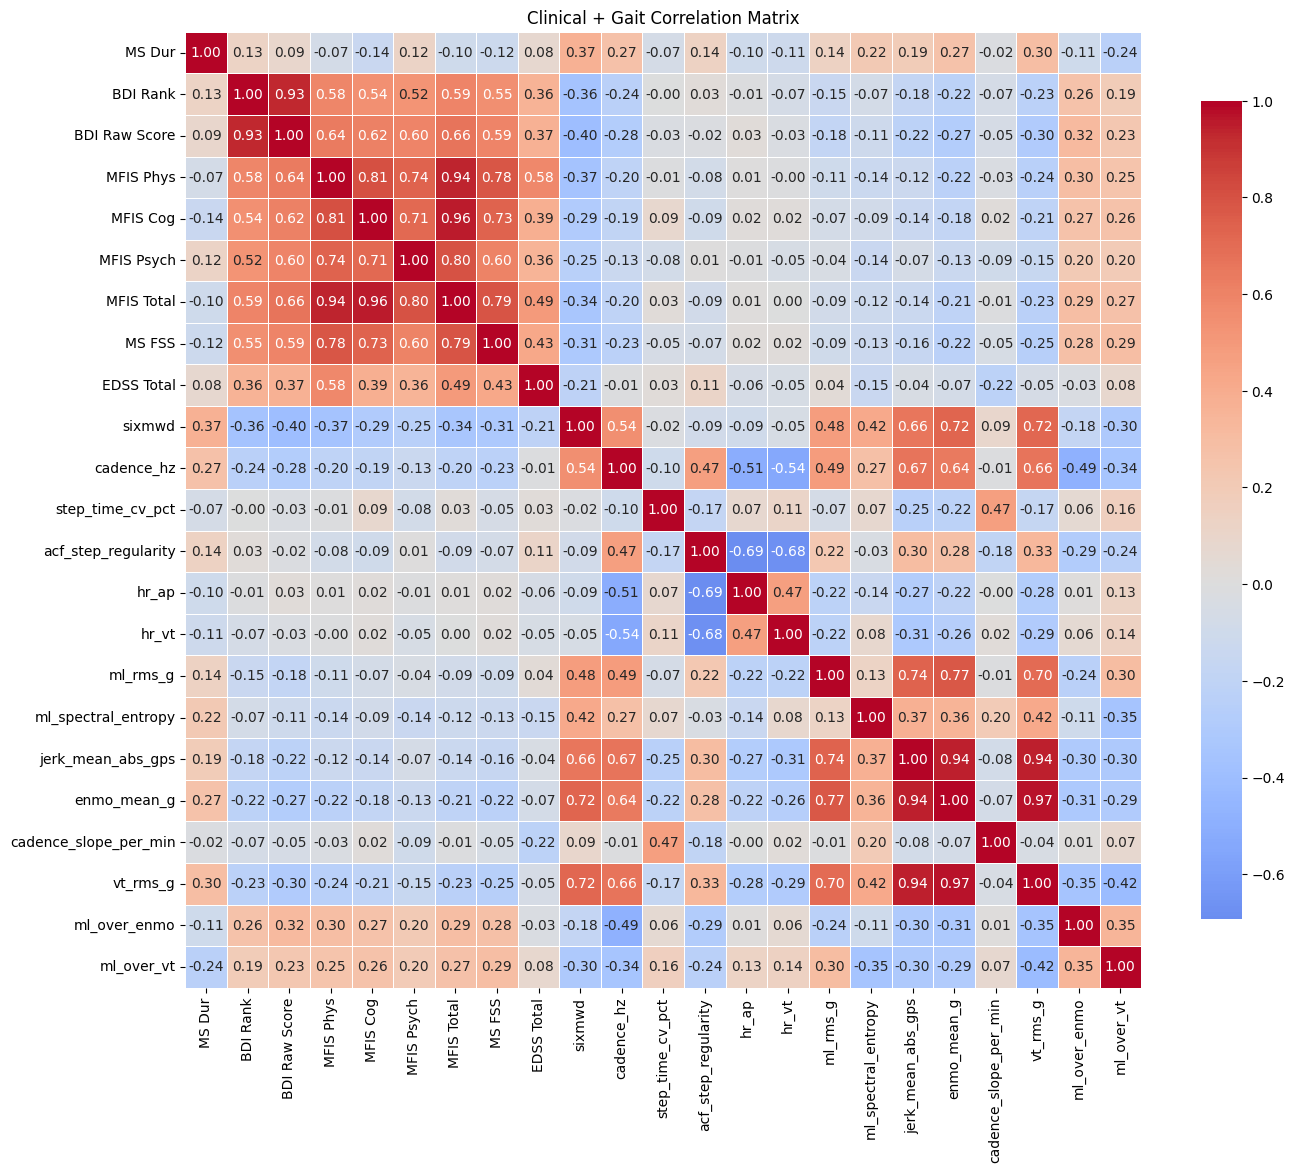

In [31]:
corr = cdf.corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)
plt.title("Clinical + Gait Correlation Matrix")
plt.tight_layout()
plt.show()